In [ ]:
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
       
import torch
import numpy as np
import warp as wp

# Initialize Warp
wp.config.verify_autograd_array_access = False
wp.config.verbose = False
wp.init()

from sphWarpCore import radiusSearchCompactHashMap, sphOperation_warp
from sphWarpCore.enumTypes import *

import matplotlib.pyplot as plt
from demo_util import *
from warpPlot import *

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:
device = torch.device('cpu')
device = torch.device('cuda')
targetNumNeighbors = 50
nx = 128
dim = 2
numParticles = nx**dim

warpOnly = False
periodic = True

kernel = KernelFunctions.Wendland2
supportMode = SupportScheme.Gather

markerSize = 8 if warpOnly else 2
gridVisualization = False 
gridResolution = 128
dx = 2.0 / nx

In [3]:
particleState, domain, adjacency, neighborhood, simulationState, measurements = prepData(nx, targetNumNeighbors, dim, device, periodic, warpOnly)
apparentVolume, crkDensity, crkState = computeCRKFactors(particleState, domain, kernel, adjacency = adjacency)

Module sphWarpCore.radiusSearch.wp_compactHash e2c9126 load on device 'cuda:0' took 5.17 ms  (cached)
Module sphWarpCore.operations.wp_density 6e0e3a3 load on device 'cuda:0' took 3.29 ms  (cached)
Module sphWarpCore.crk.crk_volume 0f6d8bf load on device 'cuda:0' took 1.65 ms  (cached)
Module sphWarpCore.crk.crk_moments 9d838a2 load on device 'cuda:0' took 2.64 ms  (cached)
Module sphWarpCore.crk.crk_density 8012a37 load on device 'cuda:0' took 4.58 ms  (cached)


Module sphWarpCore.operations.wp_gradient 588bd4a load on device 'cuda:0' took 4.23 ms  (cached)
Linear Gradient (WarpSPH):  tensor([[-2.1156e+02, -5.6563e+00],
        [-8.1481e+01, -2.5834e+00],
        [-7.2822e+00, -6.7802e-02],
        ...,
        [-4.5017e+00, -2.8615e-01],
        [-1.0994e+02, -3.1061e+00],
        [-2.1264e+02, -4.6499e+00]], device='cuda:0')
Mean Absolute Error in X Gradient:  5.047474384307861
Mean Absolute Error in Y Gradient:  0.19852375984191895


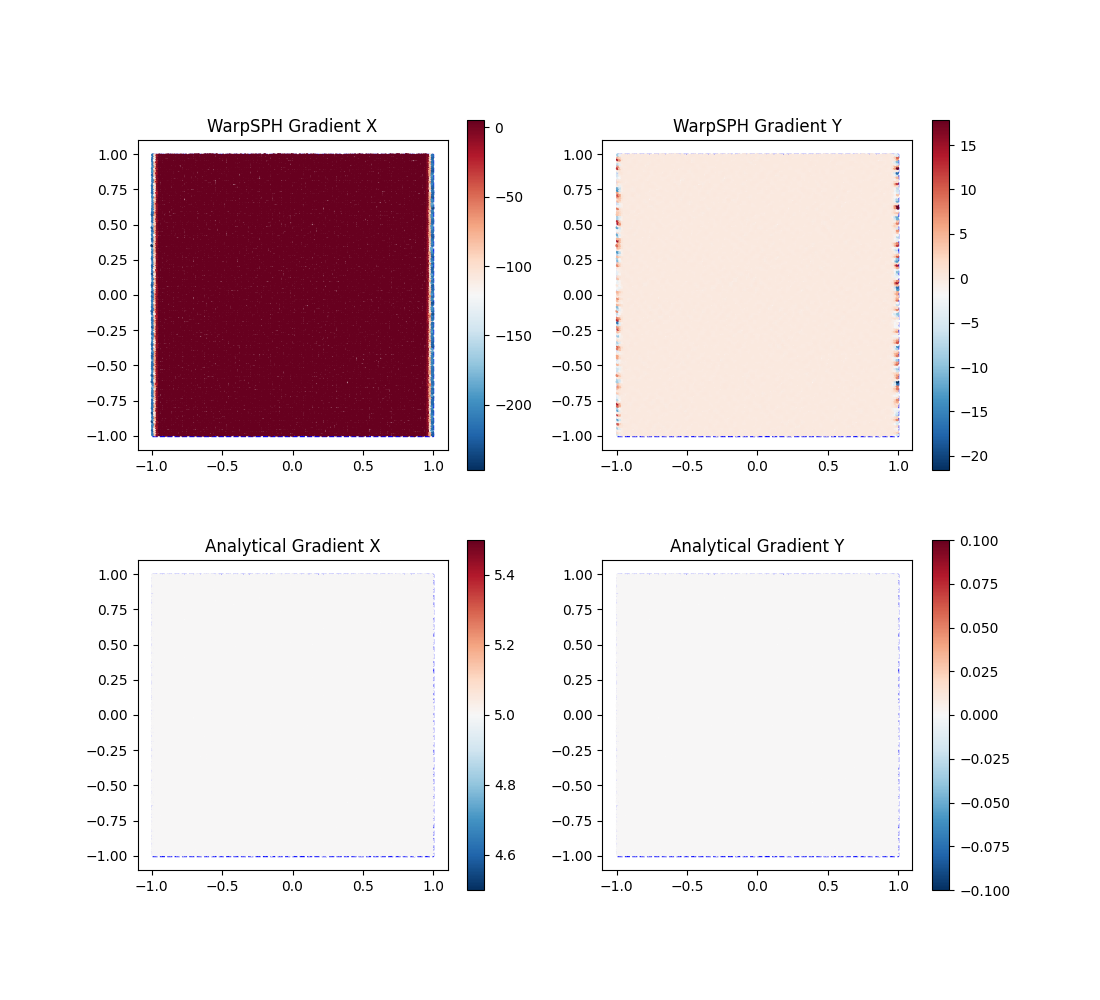

In [ ]:
f_linear = particleState.positions[:,0] * 5 + 10
f_grad_x = torch.full_like(f_linear, 5.0)
f_grad_y = torch.zeros_like(f_linear)

linear_gradient_warp = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties=OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = adjacency,
    domain = domain,
)

print("Linear Gradient (WarpSPH): ", linear_gradient_warp)

mean_error_x = torch.mean(torch.abs(linear_gradient_warp[:,0] - f_grad_x))
mean_error_y = torch.mean(torch.abs(linear_gradient_warp[:,1] - f_grad_y))

print("Mean Absolute Error in X Gradient: ", mean_error_x.item())
print("Mean Absolute Error in Y Gradient: ", mean_error_y.item())

fig, axis = plt.subplots(2,2, figsize = (11,10), squeeze=False)

plotSettings = PlottingOptions(
    colorMap = ColorMap.RdBu,
    flipColorMap = True,
    showColorBar = True,
    markerSize = markerSize,
    gridVisualization = GridVisualization(
        resolution = gridResolution,
    ) if gridVisualization else None,
)

# as the visualize function accepts kwargs we can predefine common plotting settings in a PlottingOptions dataclass and then unpack it when calling the function to keep the code cleaner and more organized, especially when we have multiple visualizations that share the same settings. This way we can easily modify the common settings in one place without having to change each individual visualization call.
# For this case we explicitly extract the gradient components before calling the visualize function
visualizeParticlesNew(fig, axis[0,0], particleState, quantity = linear_gradient_warp[:,0], domain = domain, options = plotSettings, plotTitle = "WarpSPH Gradient X");
visualizeParticlesNew(fig, axis[0,1], particleState, quantity = linear_gradient_warp[:,1], domain = domain, options = plotSettings, plotTitle = "WarpSPH Gradient Y");
visualizeParticlesNew(fig, axis[1,0], particleState, quantity = f_grad_x, domain = domain, options = plotSettings, plotTitle = "Analytical Gradient X");
visualizeParticlesNew(fig, axis[1,1], particleState, quantity = f_grad_y, domain = domain, options = plotSettings, plotTitle = "Analytical Gradient Y");

In [5]:
print("Testing Linear Interpolation with WarpSPH...")
print("Input Function: f(x,y) = 5x + 10", 'Min: ', torch.min(f_linear), "Max: ", torch.max(f_linear))
linear_interp = warpOperation(
    queryParticles = particleState,
    queryValues = f_linear,
    operationProperties=OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Interpolate,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = None,
    domain = domain,
)
print("Linear Interpolation (WarpSPH): ", linear_interp, "Min: ", torch.min(linear_interp), "Max: ", torch.max(linear_interp))

Testing Linear Interpolation with WarpSPH...
Input Function: f(x,y) = 5x + 10 Min:  tensor(5.0135, device='cuda:0') Max:  tensor(14.9784, device='cuda:0')
Module sphWarpCore.operations_grid.wp_interpolate_grid 216d30d load on device 'cuda:0' took 2.81 ms  (cached)
Linear Interpolation (WarpSPH):  tensor([ 8.1981,  5.7816,  5.1235,  ..., 14.4270, 13.7832, 11.9371],
       device='cuda:0') Min:  tensor(4.9933, device='cuda:0') Max:  tensor(15.3406, device='cuda:0')


In [6]:
f = torch.randn(numParticles, device=device, dtype=torch.float32)

f_smoothed = f.clone()

for _ in range(4):
    f_smoothed = warpOperation(
        queryParticles = particleState,
        queryValues = f_smoothed,
        operationProperties = OperationProperties(
            kernel = kernel,
            supportMode = supportMode,
            operation = WarpOperation.Interpolate,
        ),
        adjacency = adjacency,
        domain = domain,
    )

gradient_warp = warpOperation(
    queryParticles = particleState,
    queryValues = f_smoothed,
    operationProperties = OperationProperties(
        kernel = kernel,
        supportMode = supportMode,
        operation = WarpOperation.Gradient,
        gradientMode = GradientScheme.Difference,
    ),
    adjacency = adjacency,
    domain = domain,
)


if not warpOnly:
    gradient_diffSPH = SPHOperation(
        simulationState,
        quantity = f_smoothed,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Gradient,
        gradientMode=GradientMode.Difference,
        supportScheme = SupportScheme.Gather,
        correctionTerms= [],
        positiveDivergence=False
    )



Module sphWarpCore.operations.wp_interpolate eea9ac0 load on device 'cuda:0' took 2.22 ms  (cached)


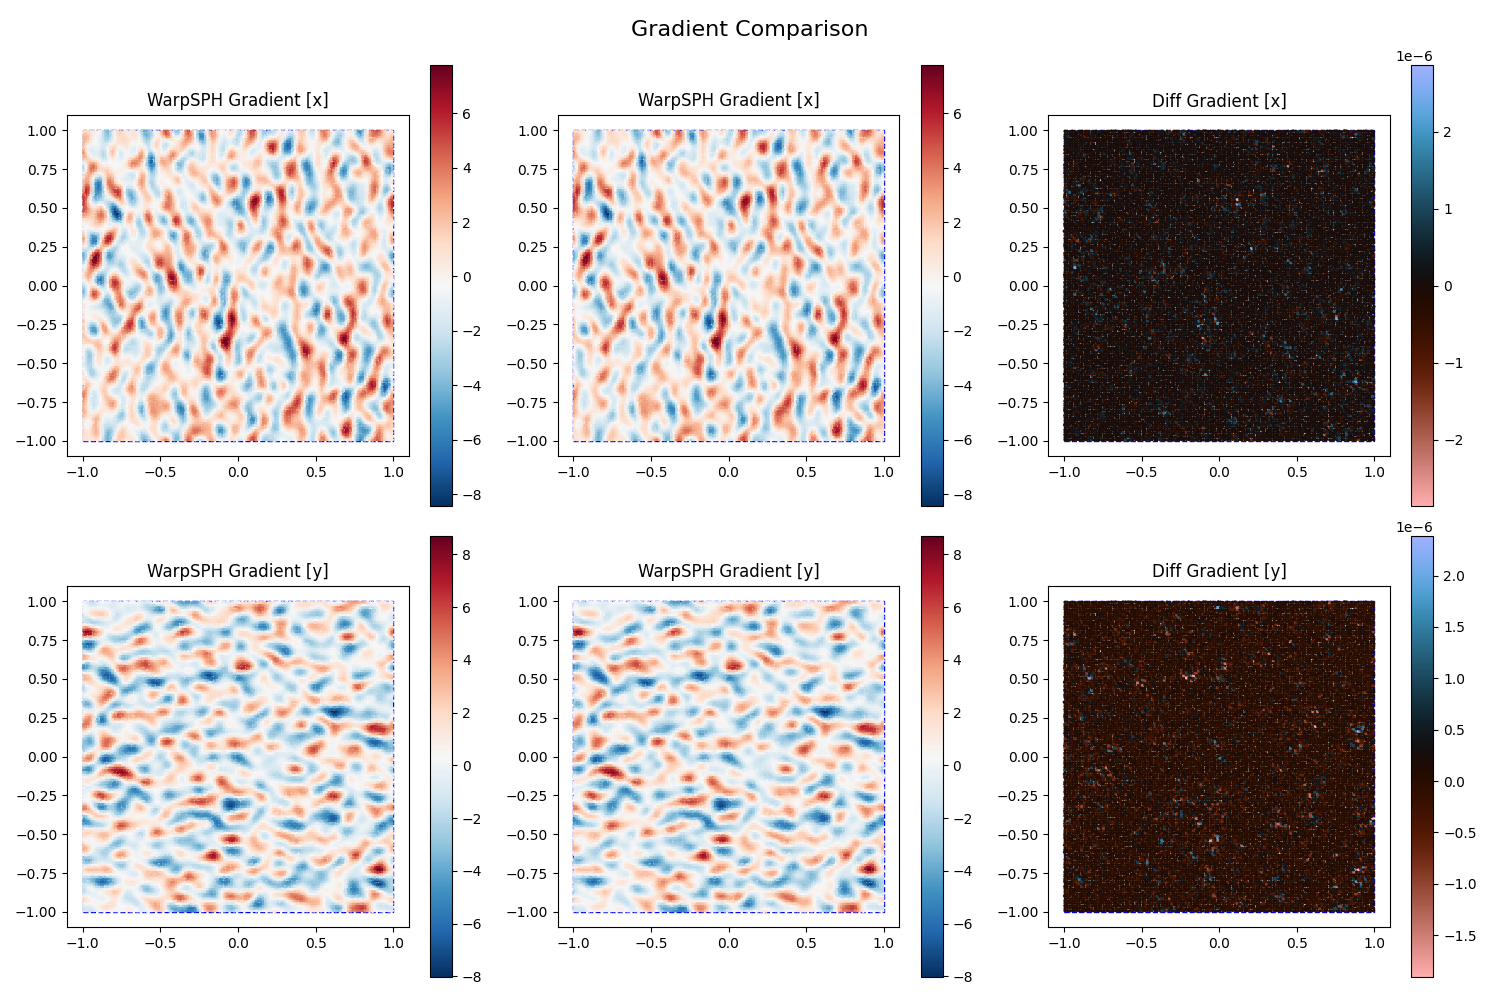

In [ ]:
fig, axis = plt.subplots(2,3 if not warpOnly else 1, figsize = (15 if not warpOnly else 11,10), squeeze=False)
markerSize = 8 if warpOnly else 2
gridVisualization = False 
gridResolution = 128

plotSettings = PlottingOptions(
    colorMap = ColorMap.RdBu,
    flipColorMap = True,
    showColorBar = True,
    markerSize = markerSize,
    gridVisualization = GridVisualization(
        resolution = gridResolution,
    ) if gridVisualization else None,
)

# We can also provide the vector quantity directly and set the mapping to extract the component internally.
visualizeParticlesNew(fig, axis[0,0], particleState, quantity = gradient_warp, domain = domain, options = plotSettings, plotTitle = "WarpSPH Gradient [x]", mapping = Mapping.x);
visualizeParticlesNew(fig, axis[1,0], particleState, quantity = gradient_warp, domain = domain, options = plotSettings, plotTitle = "WarpSPH Gradient [y]", mapping = Mapping.y);

if not warpOnly:    
    visualizeParticlesNew(fig, axis[0,1], particleState, quantity = gradient_diffSPH, domain = domain, options = plotSettings, plotTitle = "WarpSPH Gradient [x]", mapping = Mapping.x);
    visualizeParticlesNew(fig, axis[1,1], particleState, quantity = gradient_diffSPH, domain = domain, options = plotSettings, plotTitle = "WarpSPH Gradient [y]", mapping = Mapping.y);

    diff_x = gradient_warp[:,0] - gradient_diffSPH[:,0]
    diff_y = gradient_warp[:,1] - gradient_diffSPH[:,1]

    visualizeParticlesNew(fig, axis[0,2], particleState, quantity = diff_x, domain = domain, options = plotSettings, plotTitle = "Diff Gradient [x]", colorMap = ColorMap.berlin);
    visualizeParticlesNew(fig, axis[1,2], particleState, quantity = diff_y, domain = domain, options = plotSettings, plotTitle = "Diff Gradient [y]", colorMap = ColorMap.berlin);


fig.suptitle("Gradient Comparison" if not warpOnly else "WarpSPH Gradient", fontsize = 16)
fig.tight_layout()


In [8]:
from warpPlot import *

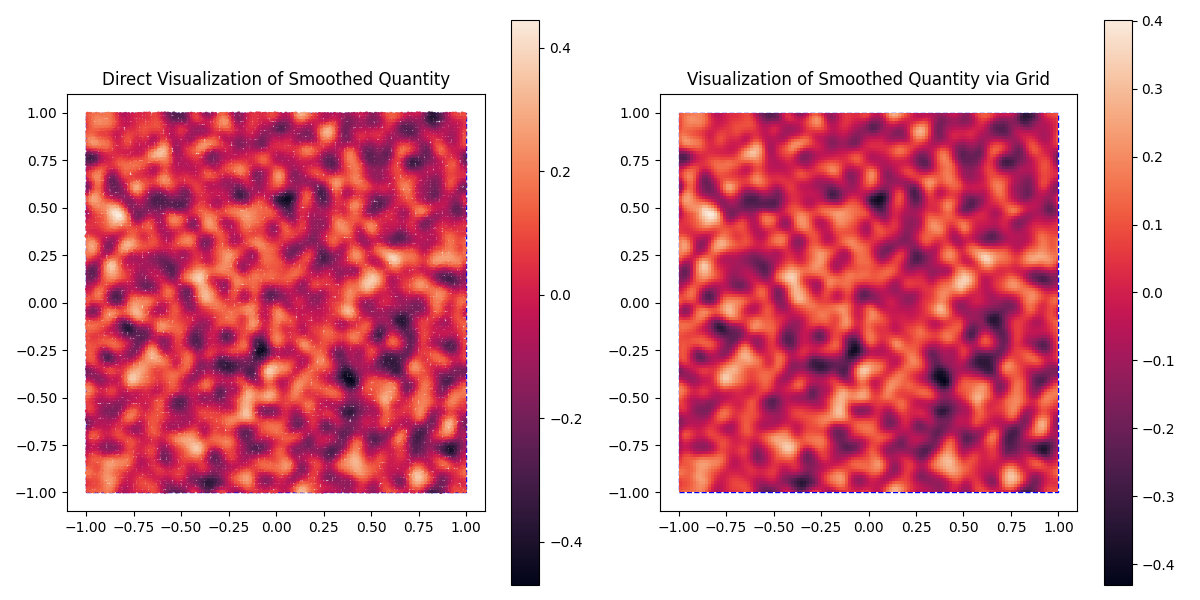

In [ ]:
fig, axis = plt.subplots(1,2, figsize=(12,6), squeeze=False)

# Here we visualize the quantity directly as a scatter plot of the particle quantities
newState = visualizeParticlesNew(
    fig, axis[0,0],
    particleState = particleState,
    domain = domain,
    quantity = f_smoothed,
    options = PlottingOptions(
        colorMap = ColorMap.rocket,
        markerSize = 4,
        midPoint = 'median',
        plotTitle = "Direct Visualization of Smoothed Quantity"
    ),
    verbose = False,
)

# This visualization shows the smooth particle field mapped onto a grid for visualization. This is particularly useful for computational efficiency as scatter plots can be slow for large particle counts, and grid-based visualization can provide a clearer picture of the overall field structure without being overwhelmed by individual particle markers. It also allows us to see the smoothed quantity in a more continuous manner, which can be helpful for understanding the underlying field behavior.
newState = visualizeParticlesNew(
    fig, axis[0,1],
    particleState = particleState,
    domain = domain,
    quantity = f_smoothed,
    options = PlottingOptions(
        colorMap = ColorMap.rocket,
        markerSize = 4,
        midPoint = 'median',
        gridVisualization = GridVisualization(
            resolution = 128,
        ),
        plotTitle = "Visualization of Smoothed Quantity via Grid"
    ),
    verbose = False,
)

fig.tight_layout()

In [10]:
# Example of updating the plot with new data (e.g., after a simulation step)
updatePlot(
    newState,
    particles = particleState,
    domain = domain,
    quantity = -f_smoothed,
    colorMap = ColorMap.viridis,
)

VisualizationState(fig=<Figure size 1200x600 with 4 Axes>, axis=<Axes: title={'center': 'Visualization of Smoothed Quantity via Grid'}>, domain=DomainDescription(min=tensor([-1., -1.], device='cuda:0'), max=tensor([1., 1.], device='cuda:0'), periodic=tensor([True, True], device='cuda:0'), dim=2), options=PlottingOptions(plottingKernel=<KernelFunctions.Wendland4: 1>, plottingOperation=None, fluidVisualization=<VisualizeOptions.Visualize: 1>, boundaryVisualization=<VisualizeOptions.Hide: 0>, showColorBar=True, colorMap=<ColorMap.viridis: 'viridis'>, flipColorMap=False, quantityScaling=<PlotScaling.Linear: 'linear'>, quantityLogThreshold=0.001, vMin=None, vMax=None, midPoint='median', domainEpsilon=0.05, markerSize=4, mapping=<Mapping.none: 'none'>, gridVisualization=GridVisualization(resolution=128, streamLines=False, streamLineOperation=None, streamLineGradientMode=<GradientScheme.Difference: 3>, streamLineLaplaceMode=<LaplacianScheme.Brookshaw: 2>, streamLinePositiveDivergence=False, s

Module sphWarpCore.operations_grid.wp_gradient_grid 6a4d6b3 load on device 'cuda:0' took 3.20 ms  (cached)


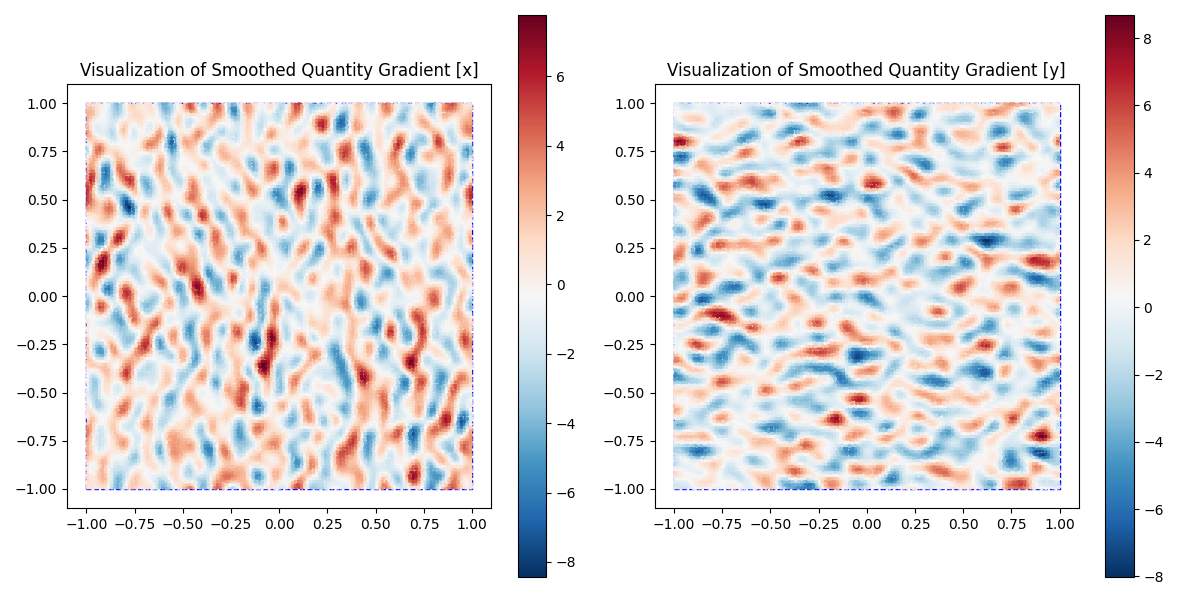

In [ ]:
fig, axis = plt.subplots(1,2, figsize=(12,6), squeeze=False)

# Here we visualize the gradient of the smoothed quantity by computing the gradient within the plotting function instead of supplying it explicitly. This allows us to see how the plotting function handles the gradient computation and visualization in one step, which can be useful for debugging and understanding the behavior of the gradient field without needing to compute it separately beforehand.
newState = visualizeParticlesNew(
    fig, axis[0,0],
    particleState = particleState,
    domain = domain,
    quantity = f_smoothed,
    options = PlottingOptions(
        colorMap = ColorMap.RdBu,
        flipColorMap = True,
        markerSize = 4,
        plottingOperation = OperationProperties(
            kernel = kernel,
            operation = WarpOperation.Gradient,
            gradientMode = GradientScheme.Difference,
        ),
        mapping=Mapping.x,
        plotTitle = "Visualization of Smoothed Quantity Gradient [x]"
    ),
    verbose = False,
)

newState = visualizeParticlesNew(
    fig, axis[0,1],
    particleState = particleState,
    domain = domain,
    quantity = f_smoothed,
    options = PlottingOptions(
        colorMap = ColorMap.RdBu,
        flipColorMap = True,
        markerSize = 4,
        plottingOperation = OperationProperties(
            kernel = kernel,
            operation = WarpOperation.Gradient,
            gradientMode = GradientScheme.Difference,
        ),
        mapping=Mapping.y,
        plotTitle = "Visualization of Smoothed Quantity Gradient [y]"
    ),
    verbose = False,
)

fig.tight_layout()

Module sphWarpCore.operations_grid.wp_interpolate_grid de3debc load on device 'cuda:0' took 3.57 ms  (cached)


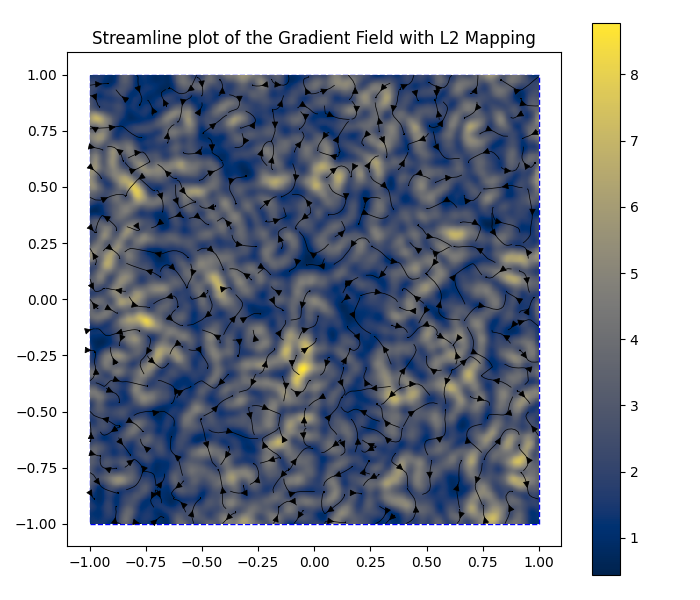

In [ ]:
fig, axis = plt.subplots(1,1, figsize=(7,6), squeeze=False)

# We can also directly visualize the gradient magnitude while plotting streamlines of the gradient field before mapping to see the raw gradient field structure without the influence of the mapping operation. This can be useful for debugging and understanding the behavior of the gradient field itself.
newState = visualizeParticlesNew(
    fig, axis[0,0],
    particleState = particleState,
    domain = domain,
    quantity = gradient_warp,
    options = PlottingOptions(
        colorMap = ColorMap.cividis,
        showColorBar = True,
        markerSize = 2,
        midPoint = 'median',
        quantityScaling = PlotScaling.Linear,
        mapping = Mapping.L2,
        plottingOperation = None,
        gridVisualization = GridVisualization(
            resolution = 512,
            streamLines = True,
            streamLineOperationLocation=StreamLineLocation.BeforeMapping,
            streamLineOperation=None
        ),
        plotTitle = "Streamline plot of the Gradient Field with L2 Mapping"
    ),
    verbose = False,
)

fig.tight_layout()

In [13]:
updatePlot(
    newState,
    particles = particleState,
    domain = domain,
    quantity = gradient_warp,
    colorMap = ColorMap.viridis,
)

VisualizationState(fig=<Figure size 700x600 with 2 Axes>, axis=<Axes: title={'center': 'Streamline plot of the Gradient Field with L2 Mapping'}>, domain=DomainDescription(min=tensor([-1., -1.], device='cuda:0'), max=tensor([1., 1.], device='cuda:0'), periodic=tensor([True, True], device='cuda:0'), dim=2), options=PlottingOptions(plottingKernel=<KernelFunctions.Wendland4: 1>, plottingOperation=None, fluidVisualization=<VisualizeOptions.Visualize: 1>, boundaryVisualization=<VisualizeOptions.Hide: 0>, showColorBar=True, colorMap=<ColorMap.viridis: 'viridis'>, flipColorMap=False, quantityScaling=<PlotScaling.Linear: 'linear'>, quantityLogThreshold=0.001, vMin=None, vMax=None, midPoint='median', domainEpsilon=0.05, markerSize=2, mapping=<Mapping.L2: 'L2'>, gridVisualization=GridVisualization(resolution=512, streamLines=True, streamLineOperation=None, streamLineGradientMode=<GradientScheme.Difference: 3>, streamLineLaplaceMode=<LaplacianScheme.Brookshaw: 2>, streamLinePositiveDivergence=Fals